# Analysis of transaction features before the attack

In [2]:
from parameters import Parameters, CardSimParameters, PPOParameters, ClassificationParameters, EnvParameters
import polars as pl


params = Parameters(
    cardsim=CardSimParameters.paper_params(with_modification=False, ulb_data=False),
    agent=PPOParameters(),
    clf_params=ClassificationParameters(use_anomaly=True),
    env_params=EnvParameters(terminal_fract=1.0, n_episodes=15_000),
)

trx, payers, terminals = params.cardsim.get_simulation_data(params.cache_dir)
trx.describe()

statistic,amount,timestamp,terminal_id,is_online,payer_id,is_fraud,is_credit
str,f64,str,f64,f64,f64,f64,f64
"""count""",1.5683696e7,"""15683696""",1.5683696e7,1.5683696e7,1.5683696e7,1.5683696e7,1.5683696e7
"""null_count""",0.0,"""0""",0.0,0.0,0.0,0.0,0.0
"""mean""",19.200598,"""2024-03-31 02:44:17.214184""",1002.48594,0.360223,9985.275205,0.010016,0.379965
"""std""",22.674593,null,577.212114,null,5768.732778,null,null
"""min""",0.08,"""2023-01-01 00:01:45""",0.0,0.0,0.0,0.0,0.0
"""25%""",6.62,"""2023-08-16 12:01:55""",507.0,null,5002.0,null,null
"""50%""",12.43,"""2024-03-31 08:05:02""",999.0,null,9971.0,null,null
"""75%""",23.32,"""2024-11-13 14:17:04""",1503.0,null,14976.0,null,null
"""max""",2566.219971,"""2025-06-28 23:57:07""",1999.0,1.0,19999.0,1.0,1.0


In [4]:
trx = trx.filter(~pl.col("is_fraud"))
trx.describe()

print(trx.quantile(0.9))
print(trx.quantile(0.95))
print(trx.quantile(0.99))

shape: (1, 7)
┌────────┬──────────────┬─────────────┬───────────┬──────────┬──────────┬───────────┐
│ amount ┆ timestamp    ┆ terminal_id ┆ is_online ┆ payer_id ┆ is_fraud ┆ is_credit │
│ ---    ┆ ---          ┆ ---         ┆ ---       ┆ ---      ┆ ---      ┆ ---       │
│ f32    ┆ datetime[μs] ┆ f64         ┆ bool      ┆ f64      ┆ bool     ┆ bool      │
╞════════╪══════════════╪═════════════╪═══════════╪══════════╪══════════╪═══════════╡
│ 40.02  ┆ null         ┆ 1802.0      ┆ null      ┆ 17984.0  ┆ null     ┆ null      │
└────────┴──────────────┴─────────────┴───────────┴──────────┴──────────┴───────────┘
shape: (1, 7)
┌───────────┬──────────────┬─────────────┬───────────┬──────────┬──────────┬───────────┐
│ amount    ┆ timestamp    ┆ terminal_id ┆ is_online ┆ payer_id ┆ is_fraud ┆ is_credit │
│ ---       ┆ ---          ┆ ---         ┆ ---       ┆ ---      ┆ ---      ┆ ---       │
│ f32       ┆ datetime[μs] ┆ f64         ┆ bool      ┆ f64      ┆ bool     ┆ bool      │
╞═══════════╪═

In [14]:
from parameters import Parameters, CardSimParameters, PPOParameters, ClassificationParameters, EnvParameters


params1 = Parameters(
    cardsim=CardSimParameters.paper_params(with_modification=False, ulb_data=False),
    agent=PPOParameters(),
    clf_params=ClassificationParameters(use_anomaly=True),
    env_params=EnvParameters(terminal_fract=1.0, n_episodes=15_000)
)
params2 = Parameters(
    cardsim=CardSimParameters.paper_params(with_modification=False, ulb_data=False),
    agent=PPOParameters(),
    clf_params=ClassificationParameters(use_anomaly=False),
    env_params=EnvParameters(terminal_fract=1.0),
)

all_data = dict[str, list[dict[str, float]]]()

## Gather features without attack

In [15]:
from datetime import timedelta
import polars as pl
from tqdm import tqdm

banksys = params1.load_banksys()
features_over_time_without_attack_with_anomaly = list[dict]()
for day in tqdm(range(60)):
    features = banksys._fast_forward(banksys.current_time + timedelta(days=1), compute_features=True, show_progress=False)
    features = pl.DataFrame(features, schema=banksys.schema)
    features_over_time_without_attack_with_anomaly.append(features.mean().to_dict())
all_data["Baseline (no anomaly)"] = features_over_time_without_attack_with_anomaly

banksys = params2.load_banksys()
features_over_time_without_attack_without_anomaly = list[dict]()
for day in tqdm(range(60)):
    features = banksys._fast_forward(banksys.current_time + timedelta(days=1), compute_features=True, show_progress=False)
    features = pl.DataFrame(features, schema=banksys.schema)
    features_over_time_without_attack_without_anomaly.append(features.mean().to_dict())
all_data["Baseline (anomaly)"] = features_over_time_without_attack_without_anomaly

100%|██████████| 60/60 [01:00<00:00,  1.00s/it]


## Gather features during the attack

In [16]:
from runner import Runner

runner1 = Runner(params1)
_ = runner1.run()

2023-03-18 avg score=5.77 - len-avg=2.36 - total=21163.31: 100%|██████████| 15000/15000 [04:20<00:00, 57.60episode/s, trx=20374]


In [17]:
runner2 = Runner(params2)
_ = runner2.run()

2023-05-21 avg score=569.97 - len-avg=11.35 - total=1367988.60: 100%|██████████| 4000/4000 [07:58<00:00,  8.35episode/s, trx=39502]


In [18]:
fot_frauds = list[dict]()
for dt, fraud in runner1.env.fraud_features.items():
    d = dt.date()
    fraud["date"] = d
    fot_frauds.append(fraud)
fot_frauds_df = pl.DataFrame(fot_frauds)
all_data["Frauds (no anomaly)"] = fot_frauds_df.group_by("date").mean().sort("date").to_dicts()

fot_frauds = list[dict]()
for dt, fraud in runner2.env.fraud_features.items():
    d = dt.date()
    fraud["date"] = d
    fot_frauds.append(fraud)
fot_frauds_df = pl.DataFrame(fot_frauds)
all_data["Frauds (anomaly)"] = fot_frauds_df.group_by("date").mean().sort("date").to_dicts()


fot_other = list[pl.DataFrame]()
for dt, other in runner1.env.other_features.items():
    d = dt.date()
    fot_other.append(other.with_columns(date=pl.lit(d)))
fot_other_df = pl.concat(fot_other)
all_data["Other (no anomaly)"] = fot_other_df.group_by("date").mean().sort("date").to_dicts()


fot_other = list[pl.DataFrame]()
for dt, other in runner2.env.other_features.items():
    d = dt.date()
    fot_other.append(other.with_columns(date=pl.lit(d)))
fot_other_df = pl.concat(fot_other)
all_data["Other (anomaly)"] = fot_other_df.group_by("date").mean().sort("date").to_dicts()

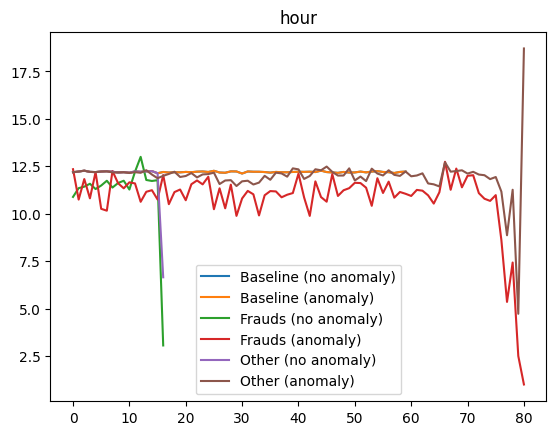

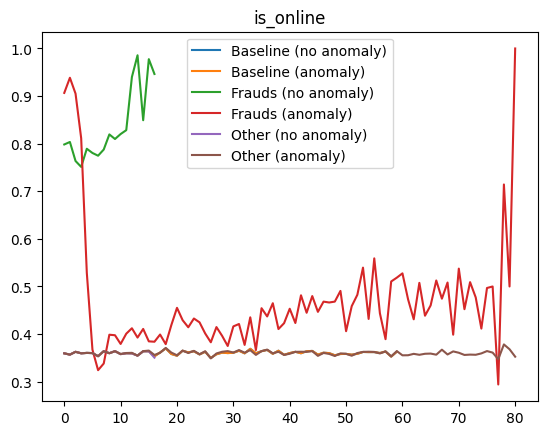

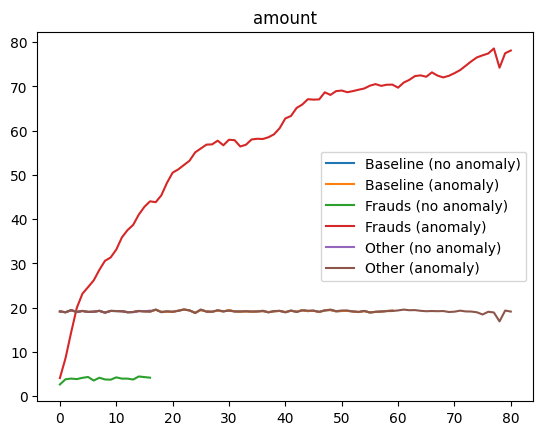

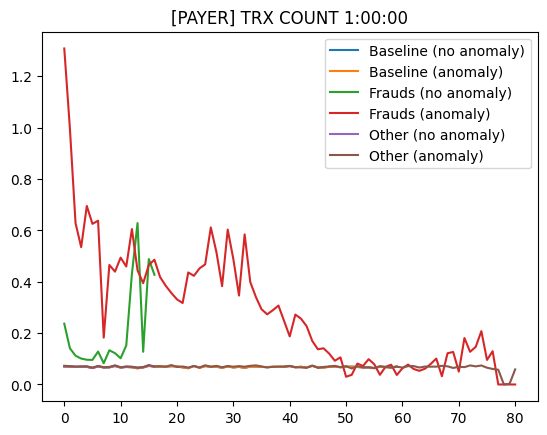

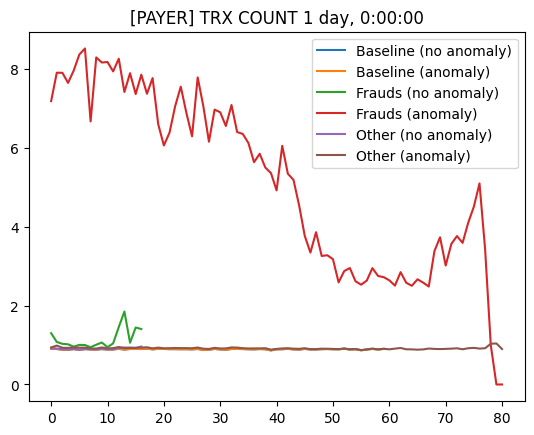

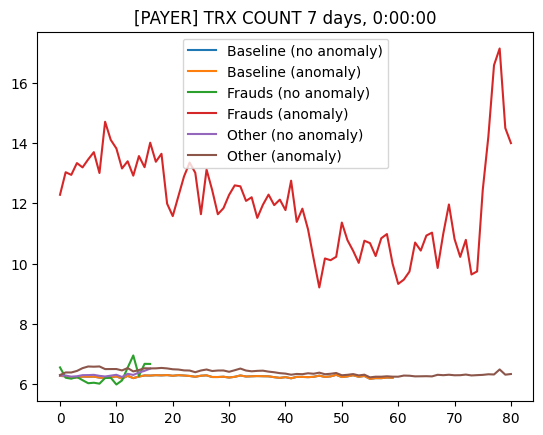

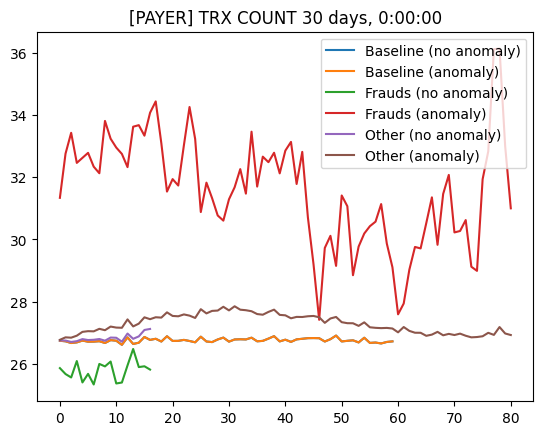

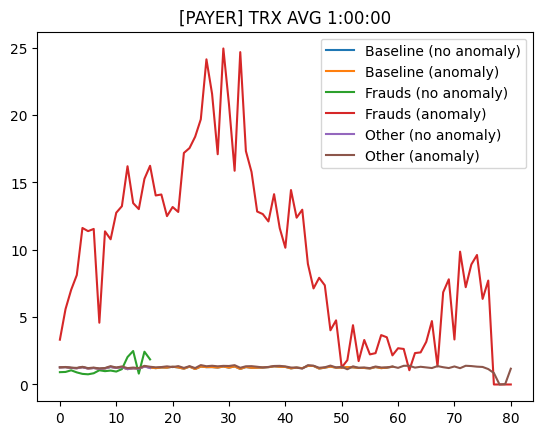

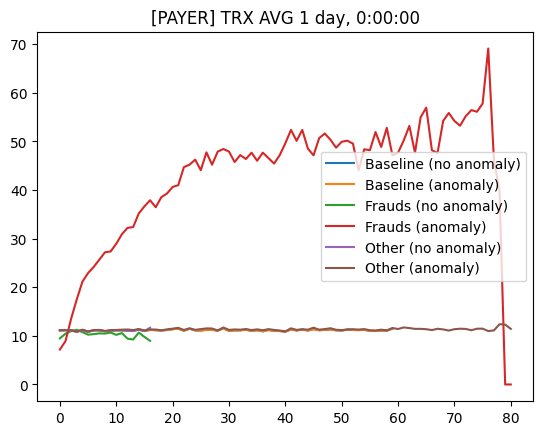

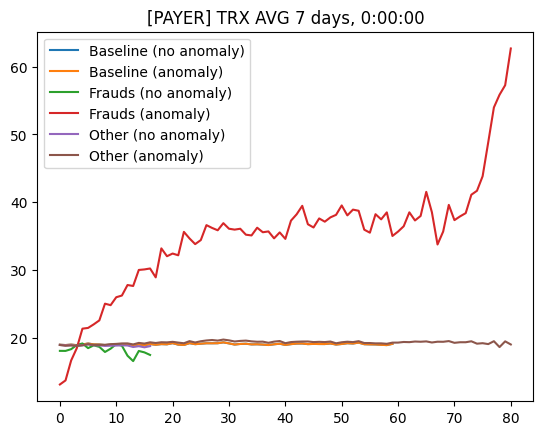

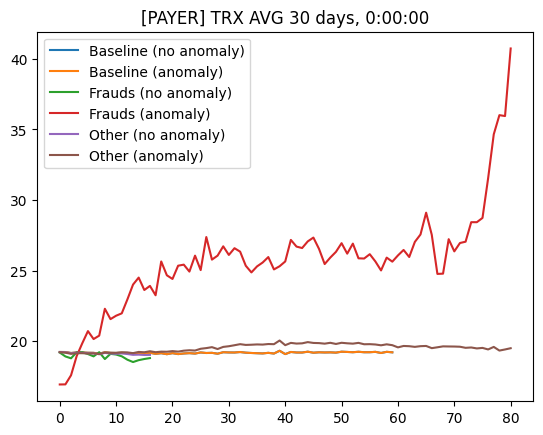

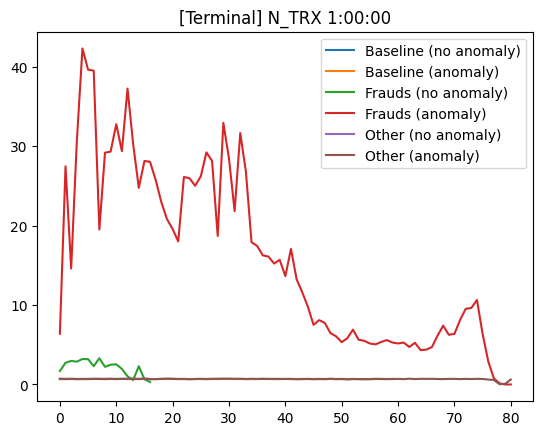

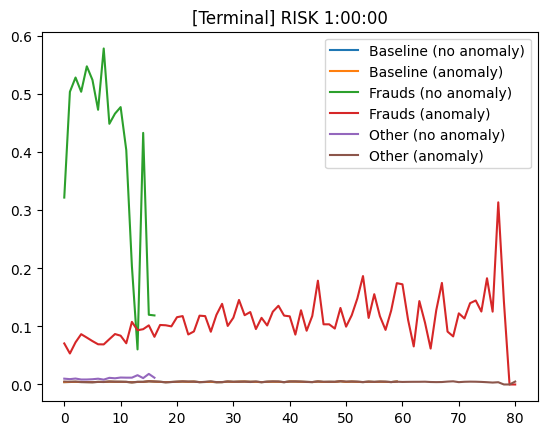

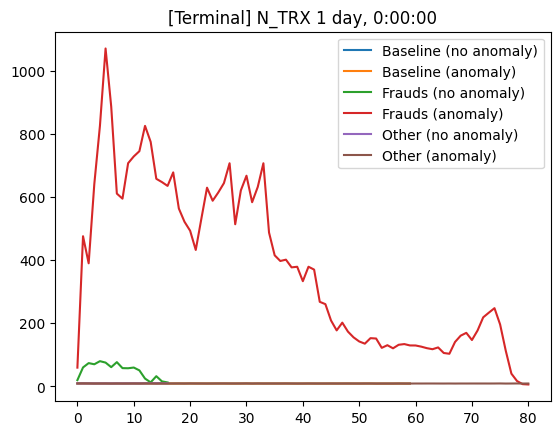

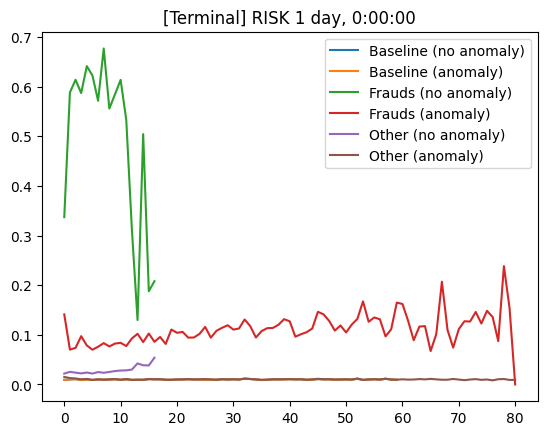

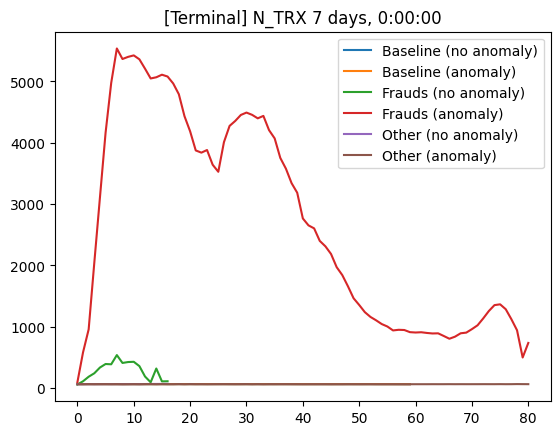

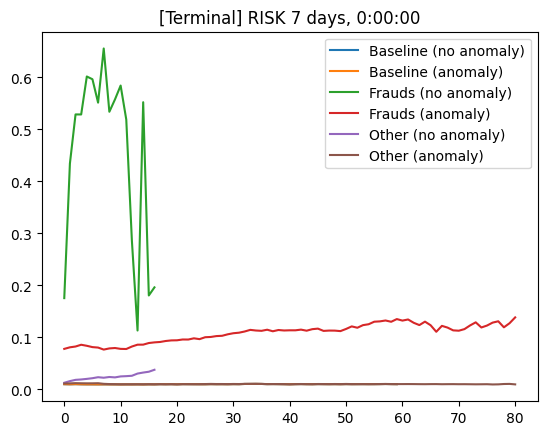

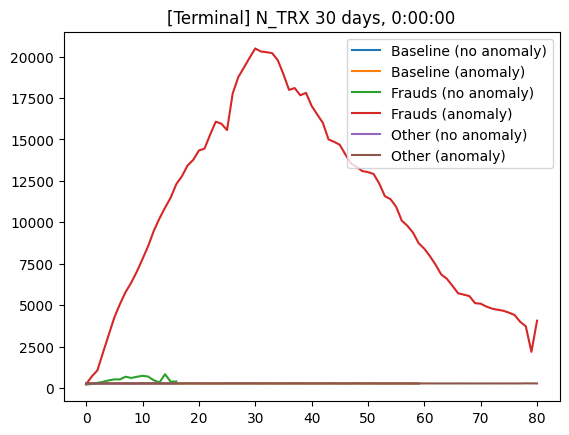

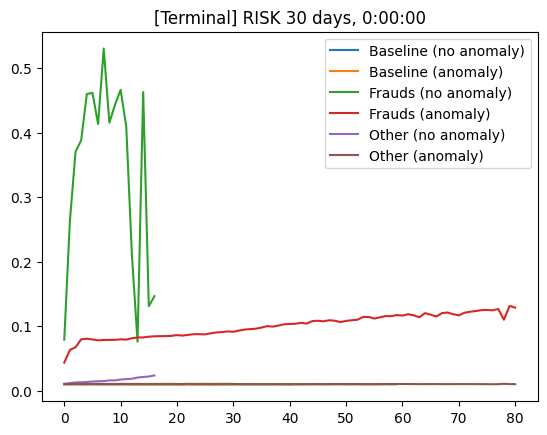

In [19]:
import matplotlib.pyplot as plt

keys = list(all_data.values())[0][0].keys()

for key in keys:
    if key in ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]:
        continue
    plt.title(key)
    for label, data in all_data.items():
        plt.plot([f[key] for f in data], label=label)
    plt.legend()
    plt.show()